# Load a pretrained model and perform inference

This notebook shows how to load a pretrained model and how to use if to perform reconstruction of plasma equilibrium and to estimate the Grad-Shafranov operator.


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
from time import time
import torch
from pathlib import Path
from tqdm import tqdm
import pandas as pd

from planetequil import PlaNet
from planetequil.utils import read_h5_numpy, dummy_planet_input_np, dummy_planet_input_tensor, load_config
from planetequil.data import PlaNetDataset
from planetequil.train import DataModule, collate_fun
from planetequil.config import Config
from planetequil.plot import contourf

from torch.utils.data import DataLoader

In [4]:
dataset = PlaNetDataset(path="../data/iter_like_data.h5", scale_inputs=False)
# dataset = PlaNetDataset(path="planet_sample_dataset.h5", scale_inputs=False)

In [5]:
dataloader = DataLoader(
    dataset=dataset,
    batch_size=1024,
    shuffle=False,
    collate_fn=collate_fun,
    num_workers=0,
    drop_last=True,
)

Loading model from ../model_hub/planet_slim_1


100%|██████████| 80/80 [00:19<00:00,  4.19it/s]


Loading model from ../model_hub/planet_physics_informed


100%|██████████| 80/80 [00:22<00:00,  3.62it/s]


Loading model from ../model_hub/planet_slim_2


...

100%|██████████| 80/80 [00:09<00:00,  8.63it/s]


Loading model from ../model_hub/planet_no_physics_informed


100%|██████████| 80/80 [00:22<00:00,  3.55it/s]

planet_slim_1                 0.274530
planet_physics_informed       0.123621
planet_slim_2                -0.271351
planet_slim_mlp              -0.157559
planet_no_physics_informed    4.812803
dtype: float32


array([[<Axes: title={'center': 'planet_slim_1'}>,
        <Axes: title={'center': 'planet_physics_informed'}>],
       [<Axes: title={'center': 'planet_slim_2'}>,
        <Axes: title={'center': 'planet_slim_mlp'}>],
       [<Axes: title={'center': 'planet_no_physics_informed'}>, <Axes: >]],
      dtype=object)

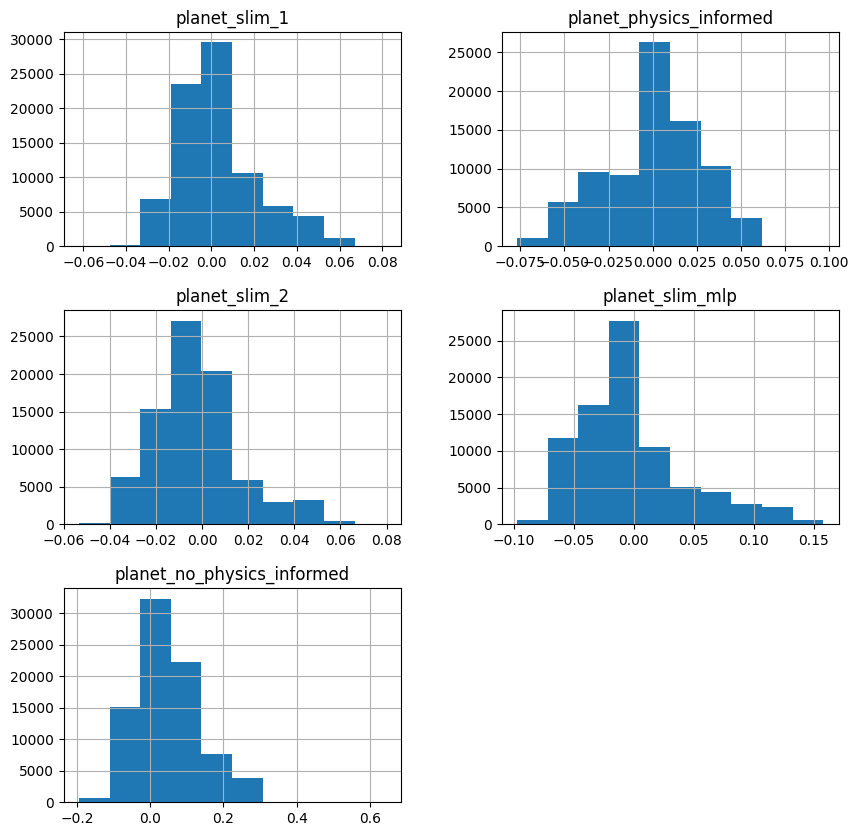

In [14]:
loss = {}
for model_path in Path("../model_hub").iterdir():
    # print(model_path.name)
    model = PlaNet.from_pretrained(path=model_path)
    loss[model_path.name] = []
    pbar = tqdm(dataloader, total=len(dataloader))
    for i, batch in enumerate(pbar):
        batch = [x.to(model.device) for x in batch]
        measures, flux, rhs, RR, ZZ, L_ker, Df_ker = batch
        inputs = {
            "measures":measures,
            "rr":RR,
            "zz":ZZ,
        }
        pred = model(**inputs)
        loss_ = (pred - flux).mean(dim=1).mean(dim=1).cpu().numpy()
        loss[model_path.name].extend(loss_)

loss_df = pd.DataFrame(loss)
print(100*loss_df.mean())
loss_df.hist(figsize=(10,10))

In [6]:
# data = read_h5_numpy("../data/iter_like_data.h5")
data = read_h5_numpy("../data/iter_like_data.h5")

In [12]:
loss_flux = {}
loss_gsope = {}
batch_size = 512
n_tot = data['measures'].shape[0]//batch_size
for model_path in Path("../model_hub").iterdir():
    model = PlaNet.from_pretrained(path=model_path)
    for i in tqdm(range(n_tot), total=n_tot):
        # print(model_path.name)
        loss_flux[model_path.name] = []
        loss_gsope[model_path.name] = []

        idx = slice(i*batch_size, (i+1)*batch_size)

        flux = model(
            measures=data['measures'][idx, ...],
            rr=data['RR_grid'],
            zz=data['ZZ_grid'],
        )

        gs_ope = model.compute_gs_operator(
            flux=flux,
            rr=data['RR_grid'],
            zz=data['ZZ_grid'],
        )

        loss_flux[model_path.name].extend(np.mean(np.mean(flux-data['flux'][idx, ...], axis=1), axis=-1))
        loss_gsope[model_path.name].extend(np.mean(np.mean(gs_ope-data['rhs'][idx,1:-1,1:-1], axis=1), axis=-1))


loss_flux_df = pd.DataFrame(loss_flux)
print(100*loss_flux_df.mean())#/loss_flux_df.abs().max())

loss_gsope_df = pd.DataFrame(loss_gsope)
print(100*loss_gsope_df.mean())#/loss_gsope_df.abs().max())


Loading model from ../model_hub/planet_slim_1


100%|██████████| 160/160 [00:41<00:00,  3.83it/s]


Loading model from ../model_hub/planet_physics_informed


100%|██████████| 160/160 [00:45<00:00,  3.51it/s]


Loading model from ../model_hub/planet_slim_2


...

Loading model from ../model_hub/planet_slim_mlp


100%|██████████| 160/160 [00:32<00:00,  4.98it/s]


Loading model from ../model_hub/planet_no_physics_informed


100%|██████████| 160/160 [00:45<00:00,  3.49it/s]

planet_slim_1                 0.610617
planet_physics_informed       0.714749
planet_slim_2                -0.091334
planet_slim_mlp               0.267291
planet_no_physics_informed    6.775716
dtype: float64
planet_slim_1                -0.117226
planet_physics_informed       0.756248
planet_slim_2                 0.393112
planet_slim_mlp               0.698972
planet_no_physics_informed   -9.804984
dtype: float64


In [ ]:
flux = model(
    measures=data['measures'],
    rr=data['RR_grid'],
    zz=data['ZZ_grid'],
)

gs_ope = model.compute_gs_operator(
    flux=flux,
    rr=data['RR_grid'],
    zz=data['ZZ_grid'],)


In [ ]:
for idx_sample in range(data['measures'].shape[0]):
    planet_inputs = {
        "measures":data['measures'][:, ...],
        "rr":data['RR_grid'],
        "zz":data['ZZ_grid'],
    }
    flux = data['flux'][:, ...]
    # print(model)
    planet_inputs = {k:torch.tensor(v, dtype=torch.float32, device=model.device) for k,v in planet_inputs.items()}
    pred = model(**planet_inputs)

    print((pred.cpu().numpy() - flux).mean())

gs_ope = model.compute_gs_operator(
    flux=flux, 
    rr=data['RR_grid'],
    zz=data['ZZ_grid'],
)


-1.3877056229239275
-1.3877056229239275
-1.3877056229239275
-1.3877056229239275
-1.3877056229239275
-1.3877056229239275
-1.3877056229239275
-1.3877056229239275
-1.3877056229239275
-1.3877056229239275
-1.3877056229239275
-1.3877056229239275
-1.3877056229239275
-1.3877056229239275
-1.3877056229239275
-1.3877056229239275
-1.3877056229239275
-1.3877056229239275
-1.3877056229239275
-1.3877056229239275
-1.3877056229239275
-1.3877056229239275
-1.3877056229239275
-1.3877056229239275
-1.3877056229239275
-1.3877056229239275
-1.3877056229239275
-1.3877056229239275
-1.3877056229239275
-1.3877056229239275
-1.3877056229239275
-1.3877056229239275
-1.3877056229239275
-1.3877056229239275
-1.3877056229239275
-1.3877056229239275
-1.3877056229239275
-1.3877056229239275
-1.3877056229239275
-1.3877056229239275
-1.3877056229239275
-1.3877056229239275
-1.3877056229239275
-1.3877056229239275
-1.3877056229239275
-1.3877056229239275
-1.3877056229239275
-1.3877056229239275
-1.3877056229239275
-1.3877056229239275


ValueError: convolve2d inputs must both be 2-D arrays

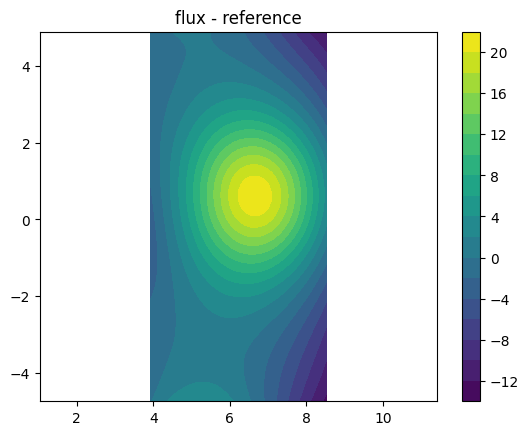

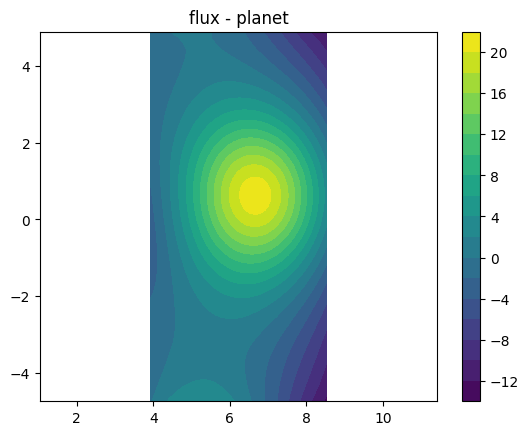

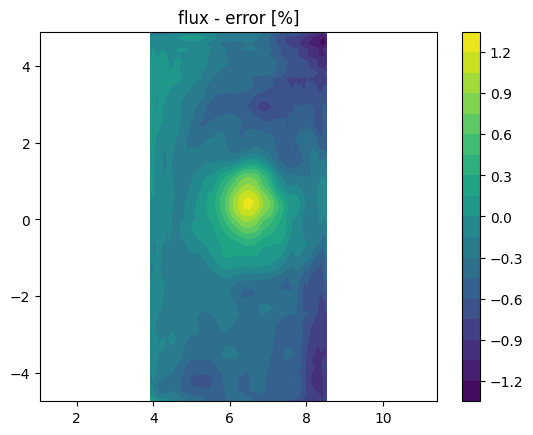

In [ ]:
contourf(data['flux'][idx_sample, ...], data['RR_grid'], data['ZZ_grid'], title="flux - reference")
contourf(flux, data['RR_grid'], data['ZZ_grid'], title="flux - planet")

scale = np.abs(data['flux'][idx_sample, ...]).max()
contourf(
    100*(data['flux'][idx_sample, ...] - flux)/data['flux'][idx_sample, ...].max(), 
    data['RR_grid'], 
    data['ZZ_grid'], 
    title='flux - error [%]'
)

In [ ]:
def time_fun(model, args, N_time=100):
    t0 = time()
    for _ in range(N_time):
        model(*args)
    return (time() - t0)/N_time

In [ ]:
dummy_inputs = dummy_planet_input_np(batch_size=32)
N_time = 100

for model_path in Path("../model_hub").iterdir():
    # print(model_path.name)
    model = PlaNet.from_pretrained(path=model_path)
    
    print(f"Model {model_path.name} - exec. time: {time_fun(model, dummy_inputs, N_time):3.3}s")
    
    

Loading model from ../model_hub/planet_slim_1
Model planet_slim_1 - exec. time: 0.00983s
Loading model from ../model_hub/planet_physics_informed
Model planet_physics_informed - exec. time: 0.0129s
Loading model from ../model_hub/planet_slim_2
Model planet_slim_2 - exec. time: 0.00978s
Loading model from ../model_hub/planet_slim_mlp
Model planet_slim_mlp - exec. time: 0.00661s
Loading model from ../model_hub/planet_no_physics_informed
Model planet_no_physics_informed - exec. time: 0.0109s


In [ ]:
dummy_inputs = dummy_planet_input_tensor(batch_size=1)
N_time = 100

for model_path in Path("../model_hub").iterdir():
    # print(model_path.name)
    model = PlaNet.from_pretrained(path=model_path)
    
    print(f"Model {model_path.name} - exec. time: {time_fun(model, dummy_inputs, N_time):3.3}s")
    
    

Loading model from ../model_hub/planet_slim_1
Model planet_slim_1 - exec. time: 0.00428s
Loading model from ../model_hub/planet_physics_informed
Model planet_physics_informed - exec. time: 0.0038s
Loading model from ../model_hub/planet_slim_2
Model planet_slim_2 - exec. time: 0.00432s
Loading model from ../model_hub/planet_slim_mlp
Model planet_slim_mlp - exec. time: 0.00365s
Loading model from ../model_hub/planet_no_physics_informed
Model planet_no_physics_informed - exec. time: 0.00374s


Assuming that you just finished your training and that you have set `save_path:  'trained_models/planet_physics_informed/'` in your config file, you can now load the pretrained model calling the `.from_pretrained(path)` class method

In [ ]:
planet = PlaNet.from_pretrained('../trained_models/planet_physics_informed/')
planet.model

PlaNetCore(
  (trunk): TrunkNet(
    (norm_r): BatchNorm2d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (norm_z): BatchNorm2d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (trunk_r): ModuleList(
      (0): Sequential(
        (0): Conv2dNornAct(
          (conv2d): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=same)
          (norm): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (act): TrainableSwish()
        )
        (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
      (1): Sequential(
        (0): Conv2dNornAct(
          (conv2d): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=same)
          (norm): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (act): TrainableSwish()
        )
        (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
      (2): S

### Laod the dataset and perform an inference step. 
Given a dataset with the same format of the one used for training (see `1_dataset_creation.ipynb`), you can use the `PlaNetDataset` class to open open it ad to compute the GS operator automatically using its `__getitem__` method. You need to specfy `nr` and `nz` (the grid sizes), that need to be the same specified during training.

In [ ]:
import h5py

# assuming you run 1_dataset_creation.ipynb
data = read_h5_numpy('planet_sample_dataset.h5')

print(data.keys())

dict_keys(['RR_grid', 'ZZ_grid', 'flux', 'measures', 'rhs'])


We can compute the reconstructed flux map $\psi(r,z)$ and the GS operator $\Delta^*\psi(r,z)$ directly using the `planet` pipeline.

In [ ]:
# call planet to predict the flux map. The pipeline will automatically scale the the input and return the flux map
idx_sample = 15
planet_inputs = {
    "measures":data['measures'][idx_sample, ...],
    "rr":data['RR_grid'],
    "zz":data['ZZ_grid'],
}
flux = planet(**planet_inputs)

gs_ope = planet.compute_gs_operator(
    flux=flux, 
    rr=data['RR_grid'],
    zz=data['ZZ_grid'],
)


We can plot the reference and reconstructed flux maps.

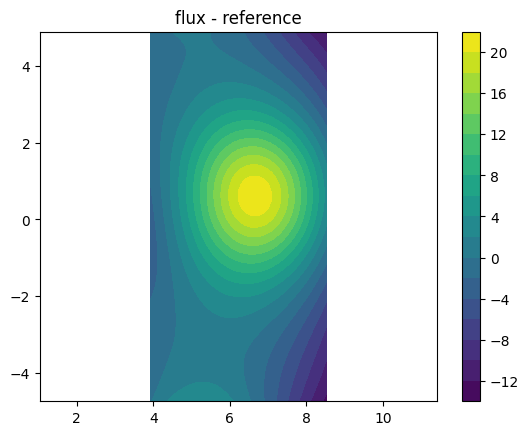

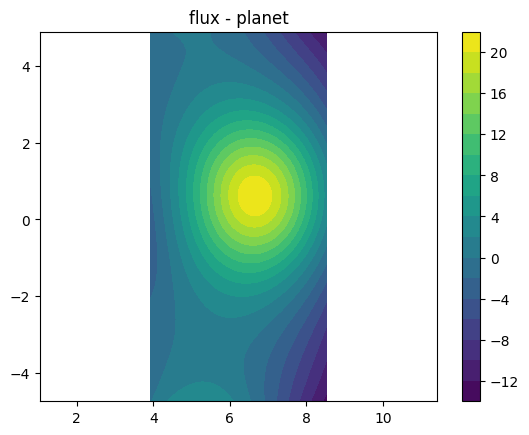

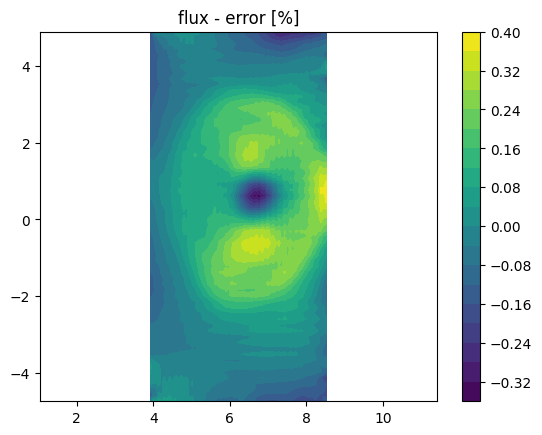

In [ ]:
contourf(data['flux'][idx_sample, ...], data['RR_grid'], data['ZZ_grid'], title="flux - reference")
contourf(flux, data['RR_grid'], data['ZZ_grid'], title="flux - planet")

scale = np.abs(data['flux'][idx_sample, ...]).max()
contourf(
    100*(data['flux'][idx_sample, ...] - flux)/data['flux'][idx_sample, ...].max(), 
    data['RR_grid'], 
    data['ZZ_grid'], 
    title='flux - error [%]'
)

As well as the Grad-Shafranov operator.

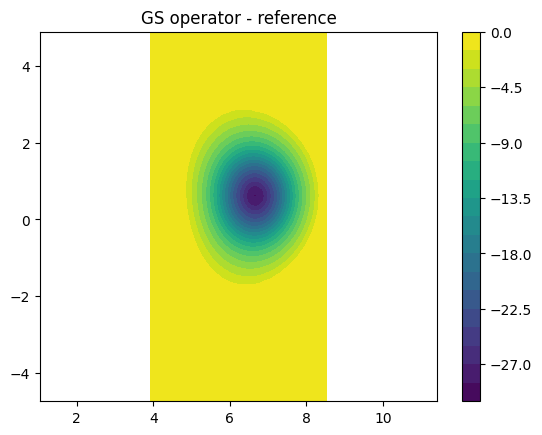

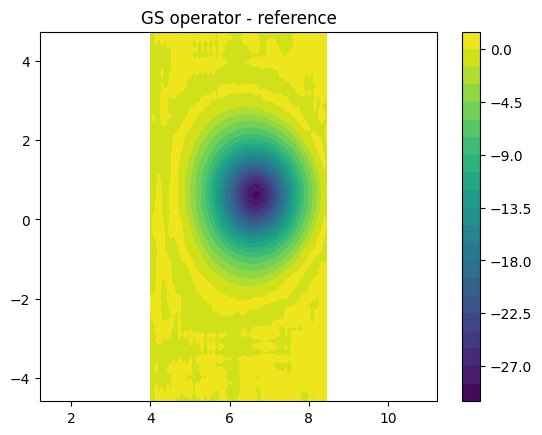

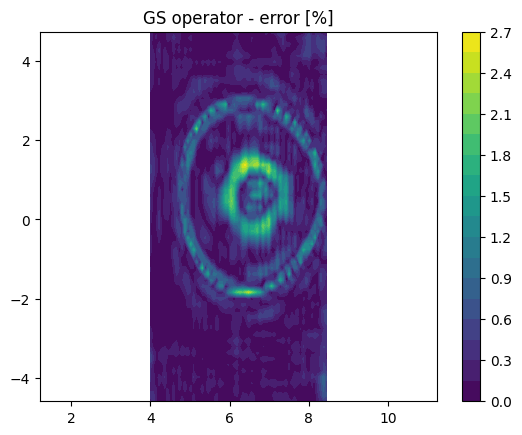

In [ ]:
contourf(data['rhs'][idx_sample, ...], data['RR_grid'], data['ZZ_grid'], title="GS operator - reference")
contourf(gs_ope, data['RR_grid'][1:-1, 1:-1], data['ZZ_grid'][1:-1, 1:-1], title="GS operator - reference")

scale = np.abs(data['rhs'][idx_sample, ...]).max()
contourf(
    100*np.abs((data['rhs'][idx_sample, ...][1:-1, 1:-1] - gs_ope))/scale, 
    data['RR_grid'][1:-1, 1:-1], 
    data['ZZ_grid'][1:-1, 1:-1], 
    title='GS operator - error [%]'
)

### Inference time
We can test the inference time on a cpu and on a gpu.

In [ ]:
N_test = 1000

t_start = time()
for _ in range(N_test):
    flux = planet(**planet_inputs)
t_end = time() - t_start

print(f"Time per reconstruction: {t_end/N_test:3.3}s")

Time per reconstruction: 0.00345s


In [ ]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

planet.model = planet.model.to(device)
planet.device = device

N_test = 1000

t_start = time()
for _ in range(N_test):
    flux = planet(**planet_inputs)
t_end = time() - t_start

print(f"Time per reconstruction: {t_end/N_test:3.3}s")


Time per reconstruction: 0.007s
